In [1]:
import pandas as pd
import numpy as np

In [2]:
etfs = pd.read_excel('data/etf_base_assets.xlsx')

In [3]:
etfs

,ETF_Index,PROVIDER,ISIN,NOM,CAPITALISATION/DISTRIBUTION,ASSVIE,PEA,SFDR,HEDGED,FRAIS DE GESTION,...,FI_Yld_Field,FI_MD_Field,last_weekly_value,last_daily_value,WEEKLY_UPDATED,DAILY_UPDATED,Deriv?,hedge_vs_EUR_for_indices_for_backtests,FX_exposition,hedge_vs_EUR_for_indices_for_exp_returns
0,0,Blackrock,IE00B5BMR087,iShares Core S&P 500 UCITS ETF USD (Acc),C,-,N,6,N,0.07,...,NaN,NaN,442.87000,442.87000,OK,OK,NaN,EUR,EUR,hedged
1,1,Ssga,IE00BZ0G8C04,SPDR® MSCI Japan EUR Hdg UCITS ETF,C,-,N,6,Y,0.17,...,Yield_to_Worst,MODIFIED_DURATION,2363.24766,2363.24766,OK,OK,NaN,EUR,USD,-
2,2,Blackrock,IE00BKBF6H24,iShares Core MSCI World UCITS ETF EUR Hedged (...,D,-,N,6,Y,0.30,...,NaN,NaN,441.34000,441.34000,OK,OK,NaN,EUR,EUR,hedged
3,3,Blackrock,IE000OHHIBC6,iShares Core MSCI World UCITS ETF USD (Dist),D,-,N,6,N,0.20,...,NaN,NaN,478.96000,478.96000,OK,OK,NaN,EUR,EUR,hedged
4,4,Blackrock,IE00B4L5Y983,iShares Core MSCI World UCITS ETF,C,-,N,6,N,0.20,...,NaN,NaN,478.96000,478.96000,OK,OK,NaN,EUR,EUR,hedged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,2351,Dws,IE00074JLU02,Xtrackers (IE) PlcJapan Net Zero Pathway Paris...,C,-,N,8,N,0.15,...,NaN,NaN,3820.62437,3820.62437,OK,OK,NaN,EUR,JPY,-
1979,2352,Dws,LU0292100046,XtrackersMSCI Korea UCITS ETF 1C,C,-,N,6,N,0.45,...,NaN,NaN,3820.62437,3820.62437,OK,OK,NaN,EUR,JPY,-
1980,2354,Dws,IE0006FDYJF8,Xtrackers (IE) PlcMSCI Japan Climate Transitio...,D,-,N,8,N,0.15,...,NaN,NaN,3820.62437,3820.62437,OK,OK,NaN,EUR,JPY,-
1981,2357,Dws,LU0322252924,XtrackersFTSE Vietnam Swap UCITS ETF 1C,C,-,N,6,N,0.85,...,NaN,NaN,3820.62437,3820.62437,OK,OK,NaN,EUR,JPY,-


In [4]:
etfs.columns

Index(['ETF_Index', 'PROVIDER', 'ISIN', 'NOM', 'CAPITALISATION/DISTRIBUTION',
       'ASSVIE', 'PEA', 'SFDR', 'HEDGED', 'FRAIS DE GESTION', 'FRAIS E/S',
       'ENCOURS SOUS GESTION', 'DEVISE AUM', 'DEVISE ETF', 'CHANGE',
       'ENCOURS SOUS GESTION (EUR)', 'CLASSE 1', 'CLASSE 2', 'CLASSE 3',
       'CLASSE 4', 'CLASSE 5', 'LIEN', 'LIEN TEXTE', 'XTB', 'ING', 'SCALABLE',
       'EASYBOURSE', 'BOURSO', 'BOURSEDIRECT', 'ETORO', 'ETF_ISIN_x',
       'ETF_Name', 'ETF_Classe_1', 'ETF_Classe_2', 'ETF_Classe_3',
       'ETF_Classe_4', 'ETF_Classe_5', 'Asset_Index', 'Asset_Name',
       'Asset_ETF_Name', 'Asset_Class', 'Asset_Geo_Area', 'Asset_Ticker',
       'Match_Score', '#', 'Name', 'Name_BBG', 'Name_report', 'Asset_class',
       'Ticker_analysis', 'Ticker_PORT_perf', 'ETF_ticker', 'ETF_bbg_name',
       'ETF_CCY', 'ETF_ISIN_y', 'EQY_Price_Ticker', 'Geo_Area',
       'EXP_MACRO_RETURN', 'geo_exp_real_growth', 'geo_exp_inflation',
       'LT_hedging_cost', 'EPS', 'Price', 'P/E', 'P/E (dire

In [5]:
list(np.unique(etfs['CLASSE 1']))

['bonds', 'cash', 'commodities', 'equities', 'securitized']

In [6]:
list(np.unique(etfs['CLASSE 2']))

['aggregate',
 'cash',
 'commodities',
 'core',
 'corporate',
 'emerging',
 'government',
 'leverage',
 'private',
 'sector',
 'short',
 'smartbeta',
 'thematic']

In [15]:
indices_prices = pd.read_excel('data/quotes.xlsx', sheet_name='indices', index_col=0, parse_dates=True)
etf_prices = pd.read_excel('data/quotes.xlsx', sheet_name='etfs', index_col=0, parse_dates=True)
indices_prices.index = pd.to_datetime(indices_prices.index, format='%Y-%m-%d')
etf_prices.index = pd.to_datetime(etf_prices.index, format='%Y-%m-%d')
etf_prices.dropna(axis=1, how='all',inplace=True)
mapping = pd.read_excel('data/quotes.xlsx', sheet_name='mapping', index_col=0)

In [16]:
mapping

,Asset
ETF,
IE00B5BMR087,SPXUXEN Index
IE00BZ0G8C04,NDDLJN Index
IE00BKBF6H24,MXWOHEUR Index
IE000OHHIBC6,NDDUWI Index
IE00B4L5Y983,NDDUWI Index
...,...
IE00074JLU02,M0JPHEUR Index
LU0292100046,M0JPHEUR Index
IE0006FDYJF8,M0JPHEUR Index


In [17]:
etf_prices

,IE00B5BMR087,IE00BZ0G8C04,IE000OHHIBC6,IE00B4L5Y983,IE00BD45KH83,IE00BKM4GZ66,IE00B3F81R35,IE00BF11F565,IE00093GOJ04,IE000WYX67F4,...,LU0592215403,XS2427363036,IE00BYNXPJ70,XS2427363895,XS2437455608,IE00074JLU02,LU0292100046,IE0006FDYJF8,LU0322252924,LU0476289623
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-19,121.75,82.01,7.0449,125.9530,5.7499,43.3090,144.0,6.23,5.987,5.514,...,1.3570,2549.0,80.22,1486.0,828.125,38.155,41.79,34.175,20.36,998.750
2025-09-12,121.75,81.88,7.0005,125.2600,5.7499,42.7506,144.0,6.23,5.983,5.509,...,1.3236,2581.0,78.90,1478.5,805.250,38.195,41.79,34.150,20.36,998.500
2025-09-05,121.75,80.05,6.8899,122.6059,5.5808,41.3203,144.0,6.23,5.983,5.509,...,1.3350,2628.5,77.47,1513.0,798.625,37.275,41.79,33.445,20.36,1002.625
2025-08-29,121.75,78.76,6.8666,122.5202,5.5808,40.6700,144.0,6.23,5.957,5.485,...,1.3310,2737.0,81.81,1526.0,767.500,37.115,41.79,33.155,20.36,991.875
2025-08-22,121.75,80.54,6.9132,121.8409,5.5808,41.2006,144.0,6.23,5.959,5.487,...,1.3690,2918.0,82.13,1603.0,722.500,37.885,41.79,33.940,20.36,1048.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
indices_prices

,SPXUXEN Index,NDDLJN Index,MXWOHEUR Index,NDDUWI Index,M4EUSI Index,CBSE NA Equity,IEAC LN EQUITY,UE27 NA Equity,M0JPHEUR Index,M1USMMT Index,...,M00IEF$O Index,DBMMFED1 Index,M7JPSC Index,IBOXUSLT Index,M1EF000V Index,LEATTREU Index,M1EFMMT Index,LF94TREH Index,LUATTRUU Index,I22547EU Index
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-19,9353.515,4244.962,468.560,13726.751,3477.29,13.136,120.63,15.363,491.70,6011.345,...,2387.47,213.1370,566.36,157.2451,769.14,245.9490,14593.98,242.8504,2412.84,241.1781
2025-09-12,9243.932,4258.451,464.140,13592.266,3442.13,13.132,120.58,15.383,493.14,5935.498,...,2367.74,212.9591,569.47,157.2229,762.06,246.3781,14519.02,243.7217,2418.54,241.6658
2025-09-05,9102.769,4176.508,457.570,13394.364,3421.03,13.130,120.63,15.340,483.58,5740.228,...,2329.46,212.7799,561.17,155.3192,733.04,246.5036,14030.56,243.2217,2412.27,242.5524
2025-08-29,9073.485,4141.616,456.130,13347.216,3403.62,13.077,120.21,15.139,479.43,5733.816,...,2323.19,212.6008,555.33,153.6619,721.60,245.5476,13779.82,241.7418,2392.78,241.6080
2025-08-22,9085.546,4180.137,457.970,13393.037,3476.72,13.092,120.36,15.180,483.71,5751.962,...,2347.44,212.4219,556.02,153.6588,733.58,246.0771,13956.98,241.5811,2388.30,241.2987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-02-04,1799.748,1049.400,103.088,2508.872,NaN,NaN,NaN,NaN,124.01,656.360,...,503.89,147.0186,139.68,NaN,208.91,149.5270,2403.00,150.9741,1389.61,144.1204
2005-01-28,1750.981,1048.280,100.706,2454.836,NaN,NaN,NaN,NaN,123.82,635.310,...,495.22,146.9487,138.05,NaN,202.72,148.8699,2372.77,150.4313,1383.65,NaN
2005-01-21,1745.340,1041.069,100.263,2443.240,NaN,NaN,NaN,NaN,122.87,632.430,...,485.29,146.8832,136.17,NaN,199.34,148.5996,2302.04,150.4018,1383.04,NaN


In [25]:
def get_inception_dates(prices):
    p = prices.sort_index(ascending=False)
    mask = p.notna()
    has_any = mask.any(axis=0)            # colonnes non entièrement NaN
    first_valid = mask.idxmin(axis=0)     # renvoie la 1ère date où True
    first_valid[~has_any] = pd.NaT    # corrige les colonnes 100% NaN
    return pd.DataFrame(first_valid, columns=['Inception Date'])

In [28]:
def get_inception_dates(prices):
    # Solution 1: Trier en ascendant et utiliser first_valid_index
    p = prices.sort_index(ascending=True)  # dates anciennes d'abord
    mask = p.notna()
    has_any = mask.any(axis=0)
    first_valid = mask.idxmax(axis=0)  # premier True = première date valide
    first_valid[~has_any] = pd.NaT
    return pd.DataFrame(first_valid, columns=['Inception Date'])
    

In [29]:
get_inception_dates(etf_prices).sort_values('Inception Date')

,Inception Date
DE000A0Q4R02,2005-01-07
FR0000021842,2005-01-07
IE00BKWQ0F09,2005-01-07
DE000A0H08G5,2005-01-07
IE00BKWQ0H23,2005-01-07
...,...
OL1285959885,2025-09-19
OL1617164998,2025-09-19
OL1285960032,2025-09-19
IE000NFR7C63,2025-09-19


In [30]:
get_inception_dates(indices_prices).sort_values('Inception Date')

,Inception Date
SPXUXEN Index,2005-01-07
M7EU Index,2005-01-07
SCXR Index,2005-01-07
NDDUPXJ Index,2005-01-07
M1WD Index,2005-01-07
M1USQU Index,2005-01-07
DBDCONIA Index,2005-01-07
M00IEF$O Index,2005-01-07
TPXDDVD Index,2005-01-07
LUATTRUU Index,2005-01-07


In [39]:
def extrapolate_etf_historical_prices(etf_prices, indices_prices, mapping):
    """
    Extrapole les séries de prix ETF vers le passé avec les rendements des indices proxy.
    Version corrigée avec gestion des valeurs non-numériques.
    """
    # Convertir les DataFrames en valeurs numériques (remplace les strings par NaN)
    etf_prices_clean = etf_prices.apply(pd.to_numeric, errors='coerce')
    indices_prices_clean = indices_prices.apply(pd.to_numeric, errors='coerce')
    
    # Calculer les dates d'inception une seule fois
    etf_inception = get_inception_dates(etf_prices_clean)
    index_inception = get_inception_dates(indices_prices_clean)
    
    # Créer DataFrame résultat avec le même index que le plus ancien DataFrame
    all_dates = indices_prices_clean.index.union(etf_prices_clean.index).sort_values()
    result_df = pd.DataFrame(index=all_dates)
    
    # 1. Pré-filtrer: trouver tous les ETFs à extrapoler en une seule fois
    valid_etfs = []
    for etf_ticker, row in mapping.iterrows():
        # Vérifier si ETF et proxy existent dans les données
        proxy_ticker = row['Asset']
        if (etf_ticker in etf_prices_clean.columns and 
            proxy_ticker in indices_prices_clean.columns and
            etf_ticker in etf_inception.index and
            proxy_ticker in index_inception.index):
            
            etf_start = etf_inception.loc[etf_ticker, 'Inception Date']
            proxy_start = index_inception.loc[proxy_ticker, 'Inception Date']
            
            # Vérifier si l'ETF commence après son proxy (extrapolation possible)
            if pd.notna(etf_start) and pd.notna(proxy_start) and etf_start > proxy_start:
                valid_etfs.append((etf_ticker, proxy_ticker, etf_start))
    
    # 2. Copier d'abord toutes les données ETF existantes
    for col in etf_prices_clean.columns:
        result_df[col] = etf_prices_clean[col]
    
    # 3. Extrapoler en une seule passe par ETF (sans boucle imbriquée sur les dates)
    for etf_ticker, proxy_ticker, etf_start in valid_etfs:
        try:
            # Obtenir le premier prix ETF à l'inception (s'assurer qu'il est numérique)
            first_etf_price = etf_prices_clean.loc[etf_start, etf_ticker]
            if pd.isna(first_etf_price):
                continue
            
            # Obtenir prix proxy à l'inception ETF (s'assurer qu'il est numérique)
            proxy_at_etf_start = indices_prices_clean.loc[etf_start, proxy_ticker]
            if pd.isna(proxy_at_etf_start) or proxy_at_etf_start == 0:
                continue
            
            # Calculer tous les ratios d'une seule fois (vectorisé)
            # Limiter aux dates avant l'inception et où proxy existe
            mask = (indices_prices_clean.index < etf_start)
            proxy_historic = indices_prices_clean.loc[mask, proxy_ticker].dropna()
            
            if len(proxy_historic) > 0:
                # Calculer tous les prix extrapolés d'un coup (opération vectorisée)
                ratio = proxy_historic / proxy_at_etf_start
                extrapolated_prices = first_etf_price * ratio
                
                # Assigner tous les prix extrapolés d'un coup
                result_df.loc[extrapolated_prices.index, etf_ticker] = extrapolated_prices
                
        except Exception as e:
            print(f"Erreur lors de l'extrapolation de {etf_ticker}: {e}")
            continue
    
    return result_df

In [40]:
etf_prices_extended = extrapolate_etf_historical_prices(etf_prices, indices_prices, mapping)

C:\Users\ramam\AppData\Local\Temp\ipykernel_13684\4023889394.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[col] = etf_prices_clean[col]
C:\Users\ramam\AppData\Local\Temp\ipykernel_13684\4023889394.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[col] = etf_prices_clean[col]
C:\Users\ramam\AppData\Local\Temp\ipykernel_13684\4023889394.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

In [41]:
etf_prices_extended

,IE00B5BMR087,IE00BZ0G8C04,IE000OHHIBC6,IE00B4L5Y983,IE00BD45KH83,IE00BKM4GZ66,IE00B3F81R35,IE00BF11F565,IE00093GOJ04,IE000WYX67F4,...,LU0592215403,XS2427363036,IE00BYNXPJ70,XS2427363895,XS2437455608,IE00074JLU02,LU0292100046,IE0006FDYJF8,LU0322252924,LU0476289623
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-07,75.781536,20.825839,1.309255,22.193202,NaN,NaN,NaN,NaN,NaN,NaN,...,1.617556,779.913320,NaN,506.834537,648.957211,14.313554,24.161809,12.825574,35.468822,1156.342288
2005-01-14,75.685246,20.764409,1.310762,22.218748,NaN,NaN,NaN,NaN,NaN,NaN,...,1.613290,774.860878,NaN,508.595239,651.211636,14.275809,24.098093,12.791753,35.375289,1153.292960
2005-01-21,74.560141,20.445067,1.296089,21.970016,NaN,NaN,NaN,NaN,NaN,NaN,...,1.588214,776.162264,NaN,512.034110,655.614809,14.053911,23.723521,12.592922,34.825429,1135.366605
2005-01-28,74.801122,20.586681,1.302240,22.074289,NaN,NaN,NaN,NaN,NaN,NaN,...,1.600494,781.674019,NaN,517.261193,662.307631,14.162572,23.906945,12.690288,35.094691,1144.144975
2005-02-04,76.884426,20.608676,1.330905,22.560190,NaN,NaN,NaN,NaN,NaN,NaN,...,1.602949,802.878965,NaN,531.704451,680.800957,14.184305,23.943630,12.709761,35.148543,1145.900648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-22,121.750000,80.540000,6.913200,121.840900,5.5808,41.2006,144.0,6.23,5.959,5.487,...,1.369000,2918.000000,82.13,1603.000000,722.500000,37.885000,41.790000,33.940000,20.360000,1048.000000
2025-08-29,121.750000,78.760000,6.866600,122.520200,5.5808,40.6700,144.0,6.23,5.957,5.485,...,1.331000,2737.000000,81.81,1526.000000,767.500000,37.115000,41.790000,33.155000,20.360000,991.875000
2025-09-05,121.750000,80.050000,6.889900,122.605900,5.5808,41.3203,144.0,6.23,5.983,5.509,...,1.335000,2628.500000,77.47,1513.000000,798.625000,37.275000,41.790000,33.445000,20.360000,1002.625000


In [49]:
etf_prices_extended.to_excel('data/etf_prices_extended.xlsx')

In [47]:
# Créer un DataFrame de comparaison des dates d'inception
etf_original_inception = get_inception_dates(etf_prices)
etf_extended_inception = get_inception_dates(etf_prices_extended)

# Créer le DataFrame de comparaison
comparison_df = pd.DataFrame(index=etf_original_inception.index)
comparison_df['Inception_Date_Original'] = etf_original_inception['Inception Date']
comparison_df['Inception_Date_Extended'] = etf_extended_inception['Inception Date']

# Calculer la différence en jours
comparison_df['Prolongation_Jours'] = (
    comparison_df['Inception_Date_Original'] - comparison_df['Inception_Date_Extended']
).dt.days

# Trier par nombre de jours de prolongation (décroissant) pour voir les ETFs les plus prolongés
comparison_df = comparison_df.sort_values('Prolongation_Jours', ascending=False)

# Afficher seulement les ETFs qui ont été prolongés (prolongation > 0)
etf_prolonged = comparison_df[comparison_df['Prolongation_Jours'] > 0]

print(f"Nombre d'ETFs prolongés: {len(etf_prolonged)}")
etf_prolonged.head(100)  # Afficher les 20 premiers

Nombre d'ETFs prolongés: 1558


,Inception_Date_Original,Inception_Date_Extended,Prolongation_Jours
IE00BFZPF546,2025-09-12,2005-01-07,7553.0
LU2345046655,2025-06-20,2005-01-07,7469.0
IE000M86QRT4,2025-06-20,2005-01-07,7469.0
LU1841731745,2025-05-30,2005-01-07,7448.0
LU0959211326,2025-05-30,2005-01-07,7448.0
...,...,...,...
IE000EFHIFG3,2023-06-30,2005-01-07,6748.0
IE000LTA2082,2023-06-30,2005-01-07,6748.0
IE000ZIJ5B20,2023-06-30,2005-01-07,6748.0
IE000JQ2IJD3,2023-06-30,2005-01-07,6748.0


ETF: IE0000VX9GN7
Date d'inception originale: 2023-06-30
Date d'inception extrapolée: 2005-01-07
Prolongation: 6748 jours


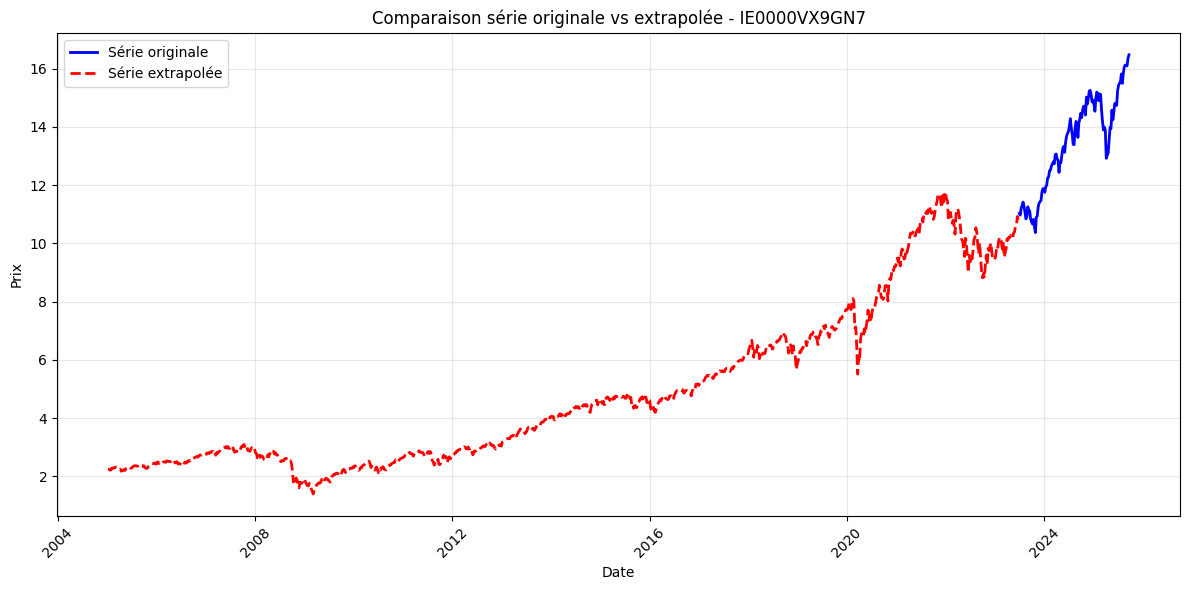

In [48]:
import matplotlib.pyplot as plt

# Sélectionner l'ETF à visualiser
etf_ticker = 'IE0000VX9GN7'

# Extraire les séries originale et extrapolée
original_series = etf_prices[etf_ticker].dropna()
extended_series = etf_prices_extended[etf_ticker].dropna()

# Créer le graphique
plt.figure(figsize=(12, 6))

# Tracer la série originale
plt.plot(original_series.index, original_series.values, 
         label='Série originale', color='blue', linewidth=2)

# Tracer la série extrapolée (seulement la partie ajoutée)
extrapolated_part = extended_series[extended_series.index < original_series.index.min()]
plt.plot(extrapolated_part.index, extrapolated_part.values, 
         label='Série extrapolée', color='red', linewidth=2, linestyle='--')

# Personnaliser le graphique
plt.title(f'Comparaison série originale vs extrapolée - {etf_ticker}')
plt.xlabel('Date')
plt.ylabel('Prix')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# Afficher les informations
original_start = original_series.index.min()
extended_start = extended_series.index.min()
prolongation = (original_start - extended_start).days

print(f"ETF: {etf_ticker}")
print(f"Date d'inception originale: {original_start.strftime('%Y-%m-%d')}")
print(f"Date d'inception extrapolée: {extended_start.strftime('%Y-%m-%d')}")
print(f"Prolongation: {prolongation} jours")

plt.show()